# 3W Toolkit

**Version:** 2.0.0  
**Authors:** Bruno Coelho Martins, Carla Pagliari, Eduardo A. B. Silva, Eduardo Henrique, Fernanda Duarte Vilela Reis de Oliveira, Gabriel Henrique Braga Lisboa, Luiza Helena de Andrade Leite, Marcello Campos, Matheus Ferreira Espirito Santo, Matheus Ramos Parracho, Natanael Moura Junior, Pedro Braga Lisboa, Rafael Padilla, Sergio Lima Netto, Thadeu Luiz Barbosa Dias, Umberto Augusto.  
**Description:** Demonstrative notebook with the main functions of *3W Toolkit*.


----

## Table of Contents 📑

1. 🚀 Introduction to 3WToolkit v2.0.0  
   1.1. Installing with `pip install`  
   1.2. Cloning & Installing  
   1.3. Forking & Installing  

2. 📂 Dataset 3W   
   2.1. Downloading the Dataset    
   2.2. Filtering & Exploring the Data   
   2.3 Cleaning the dataset   

3. ⚙️ Preprocessing   
   3.1 Handling missing values (Imputation)  
   3.2 Normalization  
   3.3 Windowing  
   3.4 Renaming columns  

4. 🔎 Feature Extraction  
   4.1 Statistical Feature Extraction  
   4.2 Wavelet Feature Extraction  
   4.3 Exponentially Weighted Statistical Feature Extraction  

5. 📊 Exploratory Analysis  
   5.1. Visualizing Time Series  

6. 🤖 Model Training and Evaluation
7. 🔗 Pipeline Integration


----

## 🚀 1. Introduction to 3WToolkit Version 2.0.0

The **3WToolkit version 2.0.0** is a **modular** and **open-source Artificial Intelligence (AI) toolkit** for **time series processing**, designed for **fault detection and classification** in the operation of **oil wells**.

Based on the experience with the original **3W Toolkit** system and using the [**3W dataset from Petrobras**](https://github.com/petrobras/3W/), the 3W Toolkit version 2.0.0 offers enhanced features such as:

- **Advanced data imputation**
- **Deep feature extraction**
- **Synthetic data augmentation**
- **High-performance computing capabilities** for model training

Please find bellow different ways to install the **3WToolkit** project hosted on GitHub: https://github.com/petrobras/3W.

------

### 1.1 Installation with `pip install`

```bash
pip install git+https://github.com/petrobras/3W.git
```

------

### 1.2. Cloning and installing


```bash
git clone https://github.com/petrobras/3W.git
cd 3W
pip install .
```

For editable/development install (`-e` installs it in editable/development mode, useful for contributing back to the original project via pull requests)

------

### 1.3. Forking and installing 


1. Fork the repository on GitHub https://github.com/petrobras/3W (button **Fork**).

![Forking the repo](../../images/forking_the_repo.jpg)


2. Clone **your forked project**:

After forking, your github account will have a copy of the 3W project.  

Run the commands below, replacing `<YOUR-USERNAME>` with your github username:
```bash
git clone https://github.com/<YOUR-USERNAME>/3W.git
cd 3W
pip install -e .
```


------

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ThreeWToolkit.dataset import ParquetDatasetConfig

from ThreeWToolkit.preprocessing import (
    ImputeMissingConfig,
    NormalizeConfig,
    RenameColumnsConfig,
)
from ThreeWToolkit.feature_extraction import (
    StatisticalConfig,
    EWStatisticalConfig,
    WaveletConfig,
    WindowingConfig,
)

from ThreeWToolkit.data_visualization import DataVisualization

-----

## 📂 2. Dataset 3W

* **Format**: Tabular, split into files in parquet format
* **Hosted** on: 3W Dataset 2.0.0 - Figshare
* **Size**: 1.67 GB
* **Splits**: 10 folders with parquet files, one folder for each event.
* **License** & Usage: Apache 2.0

**Define path**

In [2]:
dataset_path = "../../dataset"

### 2.1 Downloading the Dataset

Let’s download the dataset using the 3W library:

In [3]:
# Create and load
ds = ParquetDatasetConfig(path=dataset_path).build()
len(ds)

2026-04-15 11:59:06,521 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-15 11:59:06,522 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-15 11:59:06,523 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


2228

### 2.2 Filtering & Exploring the Data

In [4]:
# Count events
total_events = len(ds)
total_events

2228

Each event is an object containing: "signal", "label" and "metadata"

In [5]:
event_id = 0
type(ds[event_id])

ThreeWToolkit.core.dataset_outputs.DatasetOutputs

In [6]:
ds[event_id].model_fields.keys()

/tmp/ipykernel_101802/1843344414.py:1: PydanticDeprecatedSince211: Accessing the 'model_fields' attribute on the instance is deprecated. Instead, you should access this attribute from the model class. Deprecated in Pydantic V2.11 to be removed in V3.0.
  ds[event_id].model_fields.keys()


dict_keys(['signal', 'label', 'metadata'])

Lets check the "signal":

In [7]:
ds[event_id].signal

,ABER-CKGL,ABER-CKP,ESTADO-DHSV,ESTADO-M1,ESTADO-M2,ESTADO-PXO,ESTADO-SDV-GL,ESTADO-SDV-P,ESTADO-W1,ESTADO-W2,...,P-PDG,PT-P,P-TPT,QBS,QGL,T-JUS-CKP,T-MON-CKP,T-PDG,T-TPT,state
timestamp,,,,,,,,,,,,,,,,,,,,,
2017-02-01 01:02:07,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,NaN,10074540.0,NaN,0.0,84.64463,NaN,0.0,119.0781,<NA>
2017-02-01 01:02:08,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,NaN,10074540.0,NaN,0.0,84.63828,NaN,0.0,119.0781,<NA>
2017-02-01 01:02:09,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,NaN,10074540.0,NaN,0.0,84.63194,NaN,0.0,119.0781,<NA>
2017-02-01 01:02:10,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,NaN,10074540.0,NaN,0.0,84.62558,NaN,0.0,119.0781,<NA>
2017-02-01 01:02:11,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,NaN,10074540.0,NaN,0.0,84.61923,NaN,0.0,119.0781,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-02-01 06:59:56,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,NaN,10014690.0,NaN,0.0,83.44021,NaN,0.0,119.0453,0
2017-02-01 06:59:57,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,NaN,10014690.0,NaN,0.0,83.45413,NaN,0.0,119.0452,0
2017-02-01 06:59:58,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,NaN,10014690.0,NaN,0.0,83.46806,NaN,0.0,119.0451,0


Let's also check the unique values in "label" 

In [8]:
np.unique(ds[0].label)

array([ 0., nan])

In [9]:
ds[0].label

timestamp
2017-02-01 01:02:07    <NA>
2017-02-01 01:02:08    <NA>
2017-02-01 01:02:09    <NA>
2017-02-01 01:02:10    <NA>
2017-02-01 01:02:11    <NA>
                       ... 
2017-02-01 06:59:56       0
2017-02-01 06:59:57       0
2017-02-01 06:59:58       0
2017-02-01 06:59:59       0
2017-02-01 07:00:00       0
Name: class, Length: 21474, dtype: Int16

Its also possible to filter/split the dataset using different methods:

#### Split by event type:

Lets, as an example select only DRAWN and SIMULATED event types:

In [10]:
ds = ParquetDatasetConfig(path=dataset_path, event_type=["drawn", "simulated"]).build()
len(ds)  # should be much smaller

2026-04-15 11:59:06,703 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-15 11:59:06,704 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-15 11:59:06,704 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


1109

And of REAL only:

In [11]:
ds = ParquetDatasetConfig(path=dataset_path, event_type=["real"]).build()
len(ds)

2026-04-15 11:59:06,743 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-15 11:59:06,744 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-15 11:59:06,745 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


1119

Any combination of REAL, DRAWN and SIMULATED is also supported.

#### Split by event class

We may also filter by event classes. To select only events from class 0 we would do:

In [12]:
target_class = [0]
ds = ParquetDatasetConfig(path=dataset_path, target_class=target_class).build()
len(ds)

2026-04-15 11:59:06,778 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-15 11:59:06,778 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-15 11:59:06,779 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


594

In [13]:
np.unique(ds[event_id].label)

array([ 0., nan])

And only for class 2:

In [14]:
target_class = [2]
ds = ParquetDatasetConfig(path=dataset_path, target_class=target_class).build()
len(ds)

2026-04-15 11:59:06,837 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-15 11:59:06,838 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-15 11:59:06,838 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


38

In [15]:
np.unique(ds[event_id].label)

array([  0,   2, 102], dtype=int16)

And we may select multiple classes:

In [16]:
target_class = [0, 2]
ds = ParquetDatasetConfig(path=dataset_path, target_class=target_class).build()
len(ds)

2026-04-15 11:59:06,892 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-15 11:59:06,893 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-15 11:59:06,893 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


632

We may combine type and class filters as well. For REAL class 2 events:

In [17]:
target_class = [2]
ds = ParquetDatasetConfig(
    path=dataset_path, event_type=["real"], target_class=target_class
).build()
len(ds)

2026-04-15 11:59:06,928 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-15 11:59:06,929 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-15 11:59:06,929 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


22

### Split through file list

It is also possible to filter the desired events through a list of event names.

This is particularly useful to define train/test splits as the user may desire.

Given a list of event names (relative to the dataset root):

In [18]:
my_split = [
    "./0/WELL-00008_20170817140222.parquet",
    "./3/SIMULATED_00061.parquet",
    "./4/WELL-00004_20140806090103.parquet",
    "./6/SIMULATED_00117.parquet",
    "./0/WELL-00001_20170201110124.parquet",
    "./5/SIMULATED_00138.parquet",
    "./4/WELL-00005_20170624070158.parquet",
    "./8/SIMULATED_00044.parquet",
    "./5/SIMULATED_00303.parquet",
    "./9/SIMULATED_00028.parquet",
    "./8/SIMULATED_00072.parquet",
    "./7/WELL-00022_20180802233838.parquet",
    "./0/WELL-00003_20170812110000.parquet",
    "./9/SIMULATED_00115.parquet",
    "./1/SIMULATED_00025.parquet",
    "./9/SIMULATED_00065.parquet",
    "./6/SIMULATED_00041.parquet",
    "./5/SIMULATED_00329.parquet",
    "./4/WELL-00004_20141118160016.parquet",
    "./6/SIMULATED_00095.parquet",
]  # can be stored in a my_split.txt file, for instance.

len(my_split)

20

In [19]:
# get only files in split
ds = ParquetDatasetConfig(path=dataset_path, split="list", file_list=my_split).build()
len(ds)

2026-04-15 11:59:06,972 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-15 11:59:06,973 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-15 11:59:06,974 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


20

In [20]:
ds[2].label

timestamp
2014-08-06 09:01:03    <NA>
2014-08-06 09:01:04    <NA>
2014-08-06 09:01:05    <NA>
2014-08-06 09:01:06    <NA>
2014-08-06 09:01:07    <NA>
                       ... 
2014-08-06 11:59:56       4
2014-08-06 11:59:57       4
2014-08-06 11:59:58       4
2014-08-06 11:59:59       4
2014-08-06 12:00:00       4
Name: class, Length: 10738, dtype: Int16

--------

## 3. ⚙️ Preprocessing

Pre-processing is an essential step to prepare the dataset before training or evaluating models.
The 3W Toolkit provides utility classes to handle missing values, normalize data, segment time series into windows, and rename columns.

In this section, we demonstrate the usage of:

- `ImputeMissing` → Fill missing values with mean, median, or constant.
- `Normalize` → Apply L1, L2, or max normalization.
- `RenameColumns` → Rename DataFrame columns using a mapping dictionary.
- `CleanSignals` → Identifying frozen / out-of-range signals based on the interquartile
range.
- `FillLabels` → Fill missing values in the labels column.
- `RemapClass` → Remap the target classes to be a sequence.

First, we select a single event from the dataset and convert its signal to a pandas DataFrame.  
Any columns with `Period` dtype are converted to `datetime` to ensure compatibility with subsequent processing steps.  
Finally, we display the first rows of the signal to inspect the data.



In [21]:
from ThreeWToolkit.preprocessing import (
    ImputeMissingConfig,
    NormalizeConfig,
    RenameColumnsConfig,
    CleanSignalsConfig,
    FillLabelsConfig,
    RemapClassConfig,
    SequentialPreprocessingAdapterConfig,
)
from ThreeWToolkit.dataset import ParquetDatasetConfig, TransformConfig

In [22]:
# Select a single event from the dataset
event_id = 0
event = ds[event_id]
event.signal.head()

,ABER-CKGL,ABER-CKP,ESTADO-DHSV,ESTADO-M1,ESTADO-M2,ESTADO-PXO,ESTADO-SDV-GL,ESTADO-SDV-P,ESTADO-W1,ESTADO-W2,...,P-PDG,PT-P,P-TPT,QBS,QGL,T-JUS-CKP,T-MON-CKP,T-PDG,T-TPT,state
timestamp,,,,,,,,,,,,,,,,,,,,,
2017-08-17 14:02:22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
2017-08-17 14:02:23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
2017-08-17 14:02:24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
2017-08-17 14:02:25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>
2017-08-17 14:02:26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>


### 2.3 Cleaning the dataset

Some dataset tags are mostly absent. We provide functions for data cleaning and normalization.

Here we will also introduce the **SequentialPreprocessingAdapterConfig**, which allow us to create a custom pipeline of pre-processing steps. 

- This method includes thresholds for identifying frozen / out-of-range signals based on the interquartile
range (IQR) of the average and standard deviation of the signals.

- Events whose statistics (standard deviation or average) fall outside the specified IQR thresholds may be considered faulty, and will be replaced with NaN values.

- Larger IQR thresholds will be more lenient, while smaller IQR thresholds will be more strict in identifying frozen / out-of-range signals.

- Categorical signals should not be processed by this feature extractor, as the IQR-based thresholds are designed for continuous signals.

- This method also has a **missing_columns_threshold** that will be used to drop columns that are mostly NaN values. 

In [23]:
ds = ParquetDatasetConfig(path=dataset_path).build()
print(f"Columns before cleaning: {ds[0].signal.columns.tolist()}")
print(f"Original event {ds[0].signal}")

2026-04-15 11:59:07,058 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-15 11:59:07,059 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-15 11:59:07,060 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


Columns before cleaning: ['ABER-CKGL', 'ABER-CKP', 'ESTADO-DHSV', 'ESTADO-M1', 'ESTADO-M2', 'ESTADO-PXO', 'ESTADO-SDV-GL', 'ESTADO-SDV-P', 'ESTADO-W1', 'ESTADO-W2', 'ESTADO-XO', 'P-ANULAR', 'P-JUS-BS', 'P-JUS-CKGL', 'P-JUS-CKP', 'P-MON-CKGL', 'P-MON-CKP', 'P-MON-SDV-P', 'P-PDG', 'PT-P', 'P-TPT', 'QBS', 'QGL', 'T-JUS-CKP', 'T-MON-CKP', 'T-PDG', 'T-TPT', 'state']
Original event                      ABER-CKGL  ABER-CKP  ESTADO-DHSV  ESTADO-M1  ESTADO-M2  \
timestamp                                                                     
2017-02-01 01:02:07        NaN       NaN          1.0        1.0        0.0   
2017-02-01 01:02:08        NaN       NaN          1.0        1.0        0.0   
2017-02-01 01:02:09        NaN       NaN          1.0        1.0        0.0   
2017-02-01 01:02:10        NaN       NaN          1.0        1.0        0.0   
2017-02-01 01:02:11        NaN       NaN          1.0        1.0        0.0   
...                        ...       ...          ...        ...    

In [24]:
clean_signal = CleanSignalsConfig()

transformer = TransformConfig(pre_processing=clean_signal).build()
transformer.fit(ds)
transformed_ds = transformer.transform(ds)

In [25]:
print(
    f"Number of columns before cleaning: {ds[0].signal.shape[1]}, after cleaning: {transformed_ds[0].signal.shape[1]}"
)
print(f"Columns before cleaning: {transformed_ds[0].signal.columns.tolist()}")
print(f"Event after cleaning: {transformed_ds[0].signal}")

Number of columns before cleaning: 28, after cleaning: 15
Columns before cleaning: ['ESTADO-DHSV', 'ESTADO-M1', 'ESTADO-M2', 'ESTADO-PXO', 'ESTADO-SDV-GL', 'ESTADO-SDV-P', 'ESTADO-W1', 'ESTADO-W2', 'ESTADO-XO', 'P-MON-CKP', 'P-PDG', 'P-TPT', 'T-JUS-CKP', 'T-TPT', 'state']
Event after cleaning:                      ESTADO-DHSV  ESTADO-M1  ESTADO-M2  ESTADO-PXO  \
timestamp                                                            
2017-02-01 01:02:07          1.0        1.0        0.0         0.0   
2017-02-01 01:02:08          1.0        1.0        0.0         0.0   
2017-02-01 01:02:09          1.0        1.0        0.0         0.0   
2017-02-01 01:02:10          1.0        1.0        0.0         0.0   
2017-02-01 01:02:11          1.0        1.0        0.0         0.0   
...                          ...        ...        ...         ...   
2017-02-01 06:59:56          1.0        1.0        0.0         0.0   
2017-02-01 06:59:57          1.0        1.0        0.0         0.0   
2017-

### 3.1 Handling missing values (Imputation)

Function to fill missing values in a **BaseDataset** using different imputation strategies

The function accepts:  
- An imputation strategy (`strategy`) which can be:  
  - `"mean"` → fill value with the column mean  
  - `"median"` → fill value with the column median  
  - `"constant"` → fill values with a constant value
  - `"ffill"` → fill values with forward fill method
  - `"bfill"` → fill values with backward fill method 
  - `"interpolate"` → fill values with interpolate fill method 
- A constant value (`fill_value`, optional) required if the strategy is `"constant"`  

First, we can take a look at an event:


In [26]:
print(f"Original event with missing values:\n{ds[0].signal}")

Original event with missing values:
                     ABER-CKGL  ABER-CKP  ESTADO-DHSV  ESTADO-M1  ESTADO-M2  \
timestamp                                                                     
2017-02-01 01:02:07        NaN       NaN          1.0        1.0        0.0   
2017-02-01 01:02:08        NaN       NaN          1.0        1.0        0.0   
2017-02-01 01:02:09        NaN       NaN          1.0        1.0        0.0   
2017-02-01 01:02:10        NaN       NaN          1.0        1.0        0.0   
2017-02-01 01:02:11        NaN       NaN          1.0        1.0        0.0   
...                        ...       ...          ...        ...        ...   
2017-02-01 06:59:56        NaN       NaN          1.0        1.0        0.0   
2017-02-01 06:59:57        NaN       NaN          1.0        1.0        0.0   
2017-02-01 06:59:58        NaN       NaN          1.0        1.0        0.0   
2017-02-01 06:59:59        NaN       NaN          1.0        1.0        0.0   
2017-02-01 07:00

Finally, applying mean imputation and verifying the results:


In [27]:
clean_signal = CleanSignalsConfig()
impute_missing = ImputeMissingConfig(strategy="mean")

transformer = TransformConfig(
    pre_processing=SequentialPreprocessingAdapterConfig(
        steps=[clean_signal, impute_missing]
    )
).build()
transformer.fit(ds)
transformed_ds = transformer.transform(ds)

In [28]:
print(f"\nValues after mean imputation: {transformed_ds[0].signal}")


Values after mean imputation:                      ESTADO-DHSV  ESTADO-M1  ESTADO-M2  ESTADO-PXO  \
timestamp                                                            
2017-02-01 01:02:07          1.0        1.0        0.0         0.0   
2017-02-01 01:02:08          1.0        1.0        0.0         0.0   
2017-02-01 01:02:09          1.0        1.0        0.0         0.0   
2017-02-01 01:02:10          1.0        1.0        0.0         0.0   
2017-02-01 01:02:11          1.0        1.0        0.0         0.0   
...                          ...        ...        ...         ...   
2017-02-01 06:59:56          1.0        1.0        0.0         0.0   
2017-02-01 06:59:57          1.0        1.0        0.0         0.0   
2017-02-01 06:59:58          1.0        1.0        0.0         0.0   
2017-02-01 06:59:59          1.0        1.0        0.0         0.0   
2017-02-01 07:00:00          1.0        1.0        0.0         0.0   

                     ESTADO-SDV-GL  ESTADO-SDV-P  ESTADO-W

### 3.2 Normalization

Function to normalize input data using **L1**, **L2**, or **max** norm

The function accepts:  
- A norm type (`norm`) which can be:  
  - `"l1"` → normalization using the L1 norm (sum of absolute values = 1)  
  - `"l2"` → normalization using the L2 norm (Euclidean length = 1)  
  - `"max"` → normalization by dividing by the maximum absolute value  

Checking column before normalization:

In [29]:
ds[0].signal["T-TPT"].head(10)

timestamp
2017-02-01 01:02:07    119.0781
2017-02-01 01:02:08    119.0781
2017-02-01 01:02:09    119.0781
2017-02-01 01:02:10    119.0781
2017-02-01 01:02:11    119.0781
2017-02-01 01:02:12    119.0781
2017-02-01 01:02:13    119.0781
2017-02-01 01:02:14    119.0781
2017-02-01 01:02:15    119.0781
2017-02-01 01:02:16    119.0781
Name: T-TPT, dtype: float64

Applying the normalization and checking results:

In [30]:
normalize_step = NormalizeConfig(norm="l2")

transformer = TransformConfig(
    pre_processing=SequentialPreprocessingAdapterConfig(
        steps=[clean_signal, normalize_step]
    )
).build()
transformer.fit(ds)
transformed_ds = transformer.transform(ds)

In [31]:
print(f"\nValues after normalization: {transformed_ds[0].signal['T-TPT'].head(10)}")


Values after normalization: timestamp
2017-02-01 01:02:07    0.634582
2017-02-01 01:02:08    0.634582
2017-02-01 01:02:09    0.634582
2017-02-01 01:02:10    0.634582
2017-02-01 01:02:11    0.634582
2017-02-01 01:02:12    0.634582
2017-02-01 01:02:13    0.634582
2017-02-01 01:02:14    0.634582
2017-02-01 01:02:15    0.634582
2017-02-01 01:02:16    0.634582
Name: T-TPT, dtype: float64


### 3.4 Renaming columns

Function to rename columns of a DataFrame using a mapping dictionary  

The function accepts:  
- A dictionary (`columns_map`) where:  
  - Keys are the current column names  
  - Values are the new column names to assign  

Checking row names before renaming:

In [32]:
print(f"\nOriginal columns: {ds[0].signal.columns.tolist()}")


Original columns: ['ABER-CKGL', 'ABER-CKP', 'ESTADO-DHSV', 'ESTADO-M1', 'ESTADO-M2', 'ESTADO-PXO', 'ESTADO-SDV-GL', 'ESTADO-SDV-P', 'ESTADO-W1', 'ESTADO-W2', 'ESTADO-XO', 'P-ANULAR', 'P-JUS-BS', 'P-JUS-CKGL', 'P-JUS-CKP', 'P-MON-CKGL', 'P-MON-CKP', 'P-MON-SDV-P', 'P-PDG', 'PT-P', 'P-TPT', 'QBS', 'QGL', 'T-JUS-CKP', 'T-MON-CKP', 'T-PDG', 'T-TPT', 'state']


Now, renaming and checking the changes:

In [33]:
columns_map = {"ABER-CKGL": "sensor_A", "ABER-CKP": "sensor_B"}
rename_step = RenameColumnsConfig(columns_map=columns_map)

transformer = TransformConfig(pre_processing=rename_step).build()
transformer.fit(ds)
transformed_ds = transformer.transform(ds)
print(f"\nColumns after renaming: {transformed_ds[0].signal.columns.tolist()}")


Columns after renaming: ['sensor_A', 'sensor_B', 'ESTADO-DHSV', 'ESTADO-M1', 'ESTADO-M2', 'ESTADO-PXO', 'ESTADO-SDV-GL', 'ESTADO-SDV-P', 'ESTADO-W1', 'ESTADO-W2', 'ESTADO-XO', 'P-ANULAR', 'P-JUS-BS', 'P-JUS-CKGL', 'P-JUS-CKP', 'P-MON-CKGL', 'P-MON-CKP', 'P-MON-SDV-P', 'P-PDG', 'PT-P', 'P-TPT', 'QBS', 'QGL', 'T-JUS-CKP', 'T-MON-CKP', 'T-PDG', 'T-TPT', 'state']


------

## 4.  🔎 Feature Extraction


In most time-series machine learning tasks, raw signal data is not used directly to train models. Instead, we perform **feature extraction** to transform segments, or "windows", of the time-series into a set of informative features that better represent the underlying patterns. This process converts a sequence of data points into a single row of features that a model can learn from.

**IMPORTANT:** All feature extractor classes in this toolkit are designed to operate on **pre-windowed data**. This means you **must** first use the `Windowing` class to prepare your time-series. The workflow is always:

1.  **Windowing Step:**
2.  **Feature Extraction Step:**

In this notebook, we will demonstrate the three primary feature extraction methods available in the toolkit, following this two-step process.

First, we select the data for feature extraction using the functionalities presented in section 2:

In [34]:
from ThreeWToolkit.feature_extraction import (
    WindowingConfig,
    StatisticalConfig,
    WaveletConfig,
    EWStatisticalConfig,
    SequentialFeatureAdapterConfig,
    ConcatFeatureAdapterConfig,
)
from ThreeWToolkit.preprocessing import (
    ImputeMissingConfig,
    CleanSignalsConfig,
    SequentialPreprocessingAdapterConfig,
)
from ThreeWToolkit.dataset import ParquetDatasetConfig

In [35]:
ds = ParquetDatasetConfig(
    path=dataset_path,
    event_type=["real"],
).build()

print(f"Number of events in the dataset: {len(ds)}")

2026-04-15 12:02:44,153 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-15 12:02:44,154 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-15 12:02:44,155 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


Number of events in the dataset: 1119


### 4.1 Custom feature extraction pipelines: 

In order to extract features from events using the ThreeWToolkit, we will import the **TransformConfig** with **SequentialFeatureAdapterConfig** and **ConcatFeatureAdapterConfig** classes, which allow us to create custom pipelines of transformations and apply to a *ParquetDataset* instance. 

Using the **Transformer** class, the *pipeline of feature extraction* can be defined like this: 

In [36]:
transformer = TransformConfig(
    feature_extraction=SequentialFeatureAdapterConfig(
        steps=[
            WindowingConfig(),
            ConcatFeatureAdapterConfig(
                steps=[
                    StatisticalConfig(),
                    EWStatisticalConfig(),
                    WaveletConfig(),
                ]
            ),
        ]
    ),
).build()

To run the feature extraction steps, we will create a default pre processing pipeline to clean the data. 

In [37]:
pre_processing_pipeline = SequentialPreprocessingAdapterConfig(
    steps=[
        CleanSignalsConfig(),
        ImputeMissingConfig(),
    ]
)

Now that we are familiar with the class declarations, let's explore some *feature extraction* methods! 

### 4.2 Windowing

Function to segment a 1D time-series into overlapping windows and apply a specified windowing function  

The function accepts:  
- A window function (`window`, default = `"hann"`):  
  - A string for standard windows (e.g., `"hann"`, `"hamming"`)  
- A window size (`window_size`, default = 4): number of samples per window  
- An overlap ratio (`overlap`, default = 0.0): must be in the range `[0, 1)`  
- A flag (`pad_last_window`, default = False) to pad the last incomplete window with constant values  
- A padding value (`pad_value`, default = 0.0) used when `pad_last_window=True`  

In [38]:
# Define the pipeline with Windowing followed by Wavelet
data_processor = TransformConfig(
    pre_processing=pre_processing_pipeline,
    feature_extraction=WindowingConfig(window_size=128),
).build()

# Fit the data processor to the dataset (ParquetDataset) and transform the data
data_processor.fit(ds)
transformed_data = data_processor.transform(ds)

In [39]:
single_event = transformed_data[0]

print(f"Shape of the final extracted features: {single_event.signal.shape}")
print("----------------------------------------------")

print(f"Columns of the extracted features: {single_event.signal.columns}")
print("----------------------------------------------")

print(f"First few rows of the extracted features: {single_event.signal.head()}")
print("----------------------------------------------")

Shape of the final extracted features: (2688, 128)
----------------------------------------------
Columns of the extracted features: RangeIndex(start=0, stop=128, step=1)
----------------------------------------------
First few rows of the extracted features:                       0    1    2    3    4    5    6    7    8    9    ...  \
window variable                                                         ...   
0      ESTADO-DHSV    1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  ...   
       ESTADO-M1      1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  ...   
       ESTADO-M2      0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
       ESTADO-PXO     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   
       ESTADO-SDV-GL  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...   

                      118  119  120  121  122  123  124  125  126  127  
window variable                                                         
0      ESTADO-DHSV    1.0  1.0  1.0  1.0

### 4.3 Statistical Feature Extraction

This is the most common approach to feature extraction for time-series data. The `Statistical` class takes the pre-windowed data and calculates a set of standard statistical descriptors for each window. These features summarize the shape and distribution of the data within that specific time segment.

The features extracted are:
* **`mean`, `std`**: Describe the central tendency and dispersion (volatility).
* **`skew`, `kurtosis`**: Describe the shape of the distribution (asymmetry and presence of outliers).
* **`min`, `1qrt`, `med`, `3qrt`, `max`**: Provide a summary of the distribution through quartiles.

In [40]:
# Define the pipeline with Windowing followed by Wavelet
windowing_config = WindowingConfig(window_size=128)

data_processor = TransformConfig(
    pre_processing=ImputeMissingConfig(),
    feature_extraction=SequentialFeatureAdapterConfig(
        steps=[
            windowing_config,
            StatisticalConfig(features=["mean", "std", "min", "max"]),
        ]
    ),
).build()

# Fit the data processor to the dataset (ParquetDataset) and transform the data
data_processor.fit(ds)
transformed_data = data_processor.transform(ds)

In [41]:
single_event = transformed_data[0]

print(f"Shape of the final extracted features: {single_event.signal.shape}")
print("----------------------------------------------")

print(f"Columns of the extracted features: {single_event.signal.columns}")
print("----------------------------------------------")

print(f"First few rows of the extracted features: {single_event.signal.head()}")
print("----------------------------------------------")

Shape of the final extracted features: (168, 112)
----------------------------------------------
Columns of the extracted features: Index(['mean_ABER-CKGL', 'mean_ABER-CKP', 'mean_ESTADO-DHSV', 'mean_ESTADO-M1',
       'mean_ESTADO-M2', 'mean_ESTADO-PXO', 'mean_ESTADO-SDV-GL',
       'mean_ESTADO-SDV-P', 'mean_ESTADO-W1', 'mean_ESTADO-W2',
       ...
       'max_P-PDG', 'max_P-TPT', 'max_PT-P', 'max_QBS', 'max_QGL',
       'max_T-JUS-CKP', 'max_T-MON-CKP', 'max_T-PDG', 'max_T-TPT',
       'max_state'],
      dtype='str', length=112)
----------------------------------------------
First few rows of the extracted features:         mean_ABER-CKGL  mean_ABER-CKP  mean_ESTADO-DHSV  mean_ESTADO-M1  \
window                                                                    
0                  0.0            0.0               1.0             1.0   
1                  0.0            0.0               1.0             1.0   
2                  0.0            0.0               1.0             1.0 

### 4.4 Wavelet Feature Extraction

The `Wavelet` class uses a signal processing technique called the Stationary Wavelet Transform (SWT). This method decomposes the signal within each window into different frequency components, which can often capture patterns that are invisible to standard statistical measures.

For each level of decomposition, two sets of coefficients are generated:
* **Approximation Coefficients (A):** These capture the low-frequency, underlying trend of the signal. Think of it as a "smoothed" version of the signal within the window.
* **Detail Coefficients (D):** These capture the high-frequency components, representing noise, spikes, and other abrupt changes. 
These features allow a model to differentiate between the general shape of a signal and its more noisy, high-frequency texture.

In [42]:
# Define parameters that will be shared between windowing and feature extraction
# The window_size for the wavelet transform is determined by its level
LEVEL = 7
WINDOW_SIZE = 128
OVERLAP = 0.875

# Define the Windowing config
windowing_config = WindowingConfig(
    window_size=WINDOW_SIZE, overlap=OVERLAP, window="boxcar"
)

In [43]:
# Define the pipeline with Windowing followed by Wavelet
data_processor = TransformConfig(
    pre_processing=pre_processing_pipeline,
    feature_extraction=SequentialFeatureAdapterConfig(
        steps=[
            windowing_config,
            WaveletConfig(level=LEVEL),
        ]
    ),
).build()

# Fit the data processor to the dataset (ParquetDataset) and transform the data
data_processor.fit(ds)
transformed_data = data_processor.transform(ds)

In [44]:
single_event = transformed_data[0]

print(f"Shape of the final extracted features: {single_event.signal.shape}")
print("----------------------------------------------")

print(f"Columns of the extracted features: {single_event.signal.columns}")
print("----------------------------------------------")

print(f"First few rows of the extracted features: {single_event.signal.head()}")
print("----------------------------------------------")

Shape of the final extracted features: (1343, 144)
----------------------------------------------
Columns of the extracted features: Index(['A7_ESTADO-DHSV', 'A7_ESTADO-M1', 'A7_ESTADO-M2', 'A7_ESTADO-PXO',
       'A7_ESTADO-SDV-GL', 'A7_ESTADO-SDV-P', 'A7_ESTADO-W1', 'A7_ESTADO-W2',
       'A7_ESTADO-XO', 'A7_P-ANULAR',
       ...
       'A0_ESTADO-W1', 'A0_ESTADO-W2', 'A0_ESTADO-XO', 'A0_P-ANULAR',
       'A0_P-JUS-CKGL', 'A0_P-MON-CKP', 'A0_P-TPT', 'A0_T-JUS-CKP', 'A0_T-TPT',
       'A0_state'],
      dtype='str', length=144)
----------------------------------------------
First few rows of the extracted features:         A7_ESTADO-DHSV  A7_ESTADO-M1  A7_ESTADO-M2  A7_ESTADO-PXO  \
window                                                              
0            11.313708     11.313708           0.0            0.0   
1            11.313708     11.313708           0.0            0.0   
2            11.313708     11.313708           0.0            0.0   
3            11.313708     11.3

### 4.5 Exponentially Weighted Statistical Feature Extraction

The `EWStatistical` class provides a specialized version of the standard statistical features. The "EW" stands for **Exponentially Weighted**.

In this method, not all data points in a window are treated equally. Instead, more recent data points are given progressively higher weight than older points. The rate at which the importance of older data "decays" is controlled by the `decay` parameter.

This is particularly useful in scenarios where the most recent behavior within a window is more predictive of the outcome than the behavior at the beginning of the window. It creates features that are more sensitive to the latest changes in the signal.

In [45]:
# Define the pipeline with Windowing followed by Wavelet
data_processor = TransformConfig(
    pre_processing=pre_processing_pipeline,
    feature_extraction=SequentialFeatureAdapterConfig(
        steps=[
            WindowingConfig(),
            EWStatisticalConfig(window_size=WINDOW_SIZE, decay=0.9),
        ]
    ),
).build()

# Fit the data processor to the dataset (ParquetDataset) and transform the data
data_processor.fit(ds)
transformed_data = data_processor.transform(ds)

In [46]:
single_event = transformed_data[0]

print(f"Shape of the final extracted features: {single_event.signal.shape}")
print("----------------------------------------------")

print(f"Columns of the extracted features: {single_event.signal.columns}")
print("----------------------------------------------")

print(f"First few rows of the extracted features: {single_event.signal.head()}")
print("----------------------------------------------")

Shape of the final extracted features: (168, 144)
----------------------------------------------
Columns of the extracted features: Index(['ew_mean_ESTADO-DHSV', 'ew_mean_ESTADO-M1', 'ew_mean_ESTADO-M2',
       'ew_mean_ESTADO-PXO', 'ew_mean_ESTADO-SDV-GL', 'ew_mean_ESTADO-SDV-P',
       'ew_mean_ESTADO-W1', 'ew_mean_ESTADO-W2', 'ew_mean_ESTADO-XO',
       'ew_mean_P-ANULAR',
       ...
       'ew_max_ESTADO-W1', 'ew_max_ESTADO-W2', 'ew_max_ESTADO-XO',
       'ew_max_P-ANULAR', 'ew_max_P-JUS-CKGL', 'ew_max_P-MON-CKP',
       'ew_max_P-TPT', 'ew_max_T-JUS-CKP', 'ew_max_T-TPT', 'ew_max_state'],
      dtype='str', length=144)
----------------------------------------------
First few rows of the extracted features:         ew_mean_ESTADO-DHSV  ew_mean_ESTADO-M1  ew_mean_ESTADO-M2  \
window                                                              
0                       1.0                1.0                0.0   
1                       1.0                1.0                0.0   
2   

----

## 5.  📊 Exploratory Analysis


In this section we will explore and visualize some signals from the dataset.

### 5.1. Visualization Tools Overview

The 3WToolkit provides three ready-to-use visualization functions that make it easy to explore time series data:

- **`DataVisualization.plot_series(...)`**: plots a single time series in a clear and straightforward way.  
- **`DataVisualization.plot_multiple_series(...)`**: allows plotting several series together for comparison.  
- **`DataVisualization.correlation_heatmap(..._)`**: generates a correlation heatmap, helping to identify relationships between multiple features.

In the next sections we will show quick examples of how to use each of these modules.


#### Selecting an event to plot

In [47]:
ds = ParquetDatasetConfig(
    path="../../dataset",
    event_type=["real"],
).build()
sig = ds[123].signal.copy()

2026-04-15 12:03:49,703 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-15 12:03:49,704 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-15 12:03:49,705 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


#### Single Series Example

With `DataVisualization.plot_series` you can quickly visualize one feature over time.  
This is useful to understand the overall trend, variation, and gaps (missing values) in a single signal.


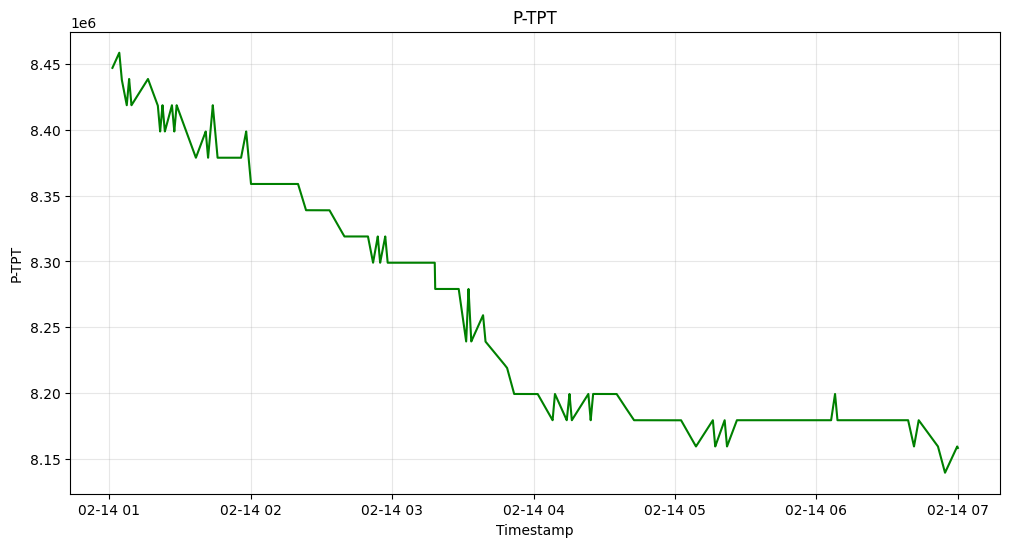

In [48]:
series = sig["P-TPT"]
fig, path = DataVisualization.plot_series(
    series=series,
    title="P-TPT",
    xlabel="Timestamp",
    ylabel="P-TPT",
    overlay_events=False,
    color="green",
)

plt.show()

#### Multiple Series Example

With function `DataVisualization.plot_multiple_series` you can display several features on the same plot.  
This is helpful when you want to compare signals directly and observe how they evolve together.


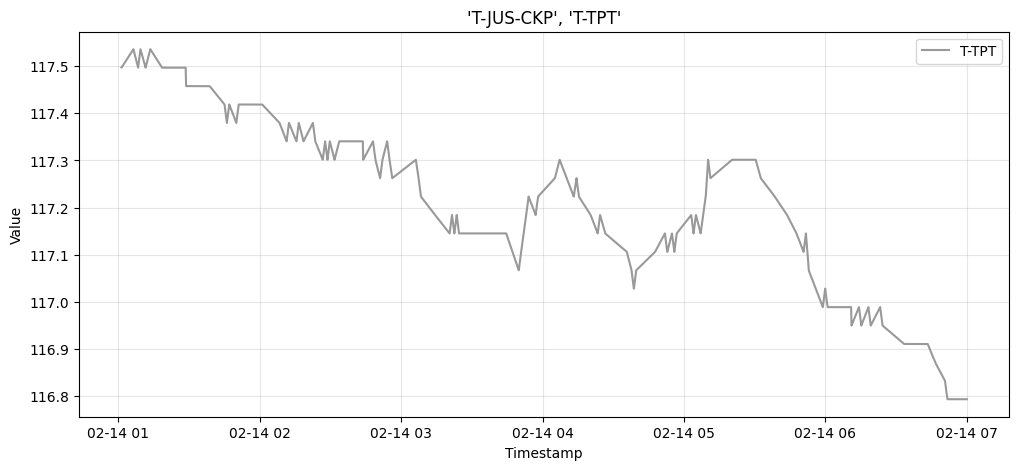

In [49]:
features = ["T-JUS-CKP", "T-TPT"]
series_list = [sig[features[0]], sig[features[1]]]

fig, axs = plt.subplots(1, 1, figsize=(12, 5))

DataVisualization.plot_multiple_series(
    series_list=series_list,
    labels=features,
    title="'T-JUS-CKP', 'T-TPT'",
    xlabel="Timestamp",
    ylabel="Value",
    ax=axs,
)

plt.show()


#### Correlation Heatmap Example

Finally, `PlotCorrelationHeatmap.correlation_heatmap` creates a heatmap of pairwise correlations.  
This is a quick way to check which features are strongly related to each other.


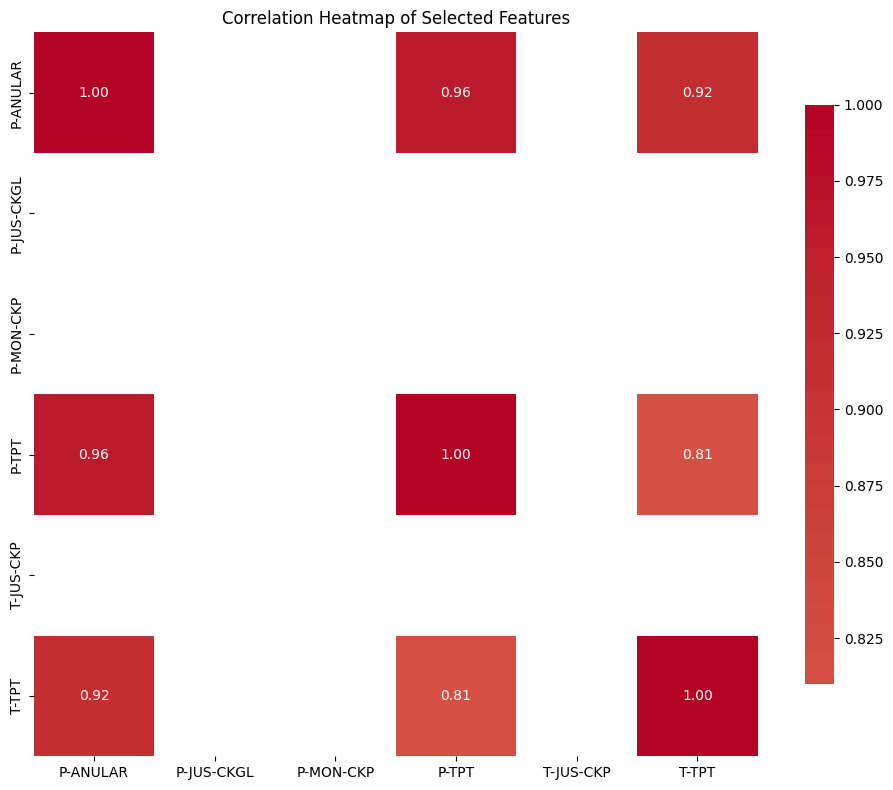

In [50]:
features = ["P-ANULAR", "P-JUS-CKGL", "P-MON-CKP", "P-TPT", "T-JUS-CKP", "T-TPT"]
subset = sig[features]

fig = DataVisualization.correlation_heatmap(
    df_of_series=subset, title="Correlation Heatmap of Selected Features"
)

plt.show()

------

## 6.  🤖 Model Training and Evaluation

## Introduction to Model Training with 3WToolkit

In this section, we introduce the process of training models using 3WToolkit, with the 3W dataset. 

The goal is to demonstrate how to transform raw time series into datasets suitable for supervised trainining, leveraging the toolkit's automation and reproducibility features.

The pipeline includes the following main steps:
- Loading the 3W dataset.
- Segmenting the signals into windows, allowing each window to be treated as an independent sample for the model.
- Training the model, using the windows as inputs and the corresponding labels as target.
- Evaluating the model performance, by computing quantitative metrics (e.g., Accuracy, Recall, F1-score, etc.) and generating visualizations of predictions versus ground truth.

First we import the relevant modules and initialize a ParquetDataset instance, defining the target classes 0, 1 and 2. 

In [51]:
from ThreeWToolkit.trainer import TorchTrainerConfig
from ThreeWToolkit.models import MLPConfig
from ThreeWToolkit.dataset import ParquetDatasetConfig, TransformConfig
from ThreeWToolkit.preprocessing import (
    SequentialPreprocessingAdapterConfig,
    CleanSignalsConfig,
    ImputeMissingConfig,
    NormalizeConfig,
)
from ThreeWToolkit.feature_extraction import (
    SequentialFeatureAdapterConfig,
    WindowingConfig,
    ConcatFeatureAdapterConfig,
    StatisticalConfig,
    EWStatisticalConfig,
    WaveletConfig,
)
from ThreeWToolkit.assessment import (
    ModelAssessmentConfig,
)
import matplotlib.pyplot as plt

RANDOM_SEED = 2026

**I. Create a ParquetDataset that loads cleaned data with target classes 0, 1, and 2**

In [52]:
# Modify this path to the folder where your dataset is downloaded
dataset_path = "../../dataset"
event_types = ["real", "simulated", "drawn"]
classes = [0, 1, 2]

ds_train = ParquetDatasetConfig(
    path=dataset_path, event_type=["real"], target_class=classes
).build()
ds_val = ParquetDatasetConfig(
    path=dataset_path, event_type=["simulated"], target_class=classes
).build()
ds_test = ParquetDatasetConfig(
    path=dataset_path, event_type=["drawn"], target_class=classes
).build()

2026-04-15 12:03:50,114 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-15 12:03:50,114 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-15 12:03:50,115 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!
2026-04-15 12:03:50,138 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-15 12:03:50,138 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-15 12:03:50,139 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!
2026-04-15 12:03:50,163 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-15 12:03:50,163 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-15 12:03:50,164 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!


**II. Preprocessing the data**

The next step is to iterate over a dataset of time series events, applying a windowing function to a selected signal column, in this case "T-TPT".

 All windowed segments from all events are then concatenated into a single DataFrame (dfs_final). This prepares the data for supervised training, where each row represents a windowed segment with its corresponding class label.

In [53]:
window_size = 128
dataset_processor = TransformConfig(
    pre_processing=SequentialPreprocessingAdapterConfig(
        steps=[
            CleanSignalsConfig(missing_column_threshold=0.65),
            ImputeMissingConfig(),
            NormalizeConfig(),
            FillLabelsConfig(),
            RemapClassConfig(),
        ]
    ),
    feature_extraction=SequentialFeatureAdapterConfig(
        steps=[
            WindowingConfig(window_size=window_size),
            ConcatFeatureAdapterConfig(
                steps=[StatisticalConfig(), EWStatisticalConfig(), WaveletConfig()]
            ),
        ]
    ),
).build()

dataset_processor.fit(ds_train)
ds_train_transformed = dataset_processor.transform(ds_train)
ds_val_transformed = dataset_processor.transform(ds_val)
ds_test_transformed = dataset_processor.transform(ds_test)

**III. Instantiating configuration classes for the MLP model, Training parameters, and Evaluation parameters.**

With the ParquetDataset instance defined, we can set the parameters for the MLP model using the MLPConfig object. These parameters will be combined with the TrainerConfig and managed through the ModelTrainer, which encapsulates the training workflow.

The defined worflow control most relevant parameters that will be used for training of a model. 

Finally, the ModelTrainer is instantiated with the training configuration, while the ModelAssessment object prepares the evaluation pipeline. The model architecture can be visualized by printing the `trainer.model`.

In [54]:
mlp_config = MLPConfig(
    hidden_sizes=(32, 16),
    output_size=dataset_processor.num_classes,
)

trainer = TorchTrainerConfig(
    seed=RANDOM_SEED,
    config_model=mlp_config,
    learning_rate=0.001,
    batch_size=64,
    epochs=10,
).build()

2026-04-15 12:04:15,107 | INFO | ThreeWToolkit.core.base_trainer | Initialized TorchTrainer with seed=2026
2026-04-15 12:04:15,108 | INFO | ThreeWToolkit.trainer.torch_trainer | TorchTrainer initialized | device=cuda | epochs=10 | batch_size=64


**IV. Training**

Finally we can call the train function using the trainer object. 

In [55]:
train_results = trainer.train(
    train_dataset=ds_train_transformed, val_dataset=ds_val_transformed
)

2026-04-15 12:04:15,116 | INFO | ThreeWToolkit.core.base_trainer | Starting training | train_size=620 | val_size=130
2026-04-15 12:04:15,227 | INFO | ThreeWToolkit.core.base_trainer | Dataset validation passed
2026-04-15 12:04:15,228 | INFO | ThreeWToolkit.core.base_trainer | Preparing training data...
2026-04-15 12:04:15,228 | INFO | ThreeWToolkit.trainer.torch_trainer | Converting dataset to DataLoader (size=620)
2026-04-15 12:04:38,707 | INFO | ThreeWToolkit.trainer.torch_trainer | Created DataLoader | batches=1552
2026-04-15 12:04:38,710 | INFO | ThreeWToolkit.core.base_trainer | Preparing validation data...
2026-04-15 12:04:38,710 | INFO | ThreeWToolkit.trainer.torch_trainer | Converting dataset to DataLoader (size=130)
2026-04-15 12:04:48,083 | INFO | ThreeWToolkit.trainer.torch_trainer | Created DataLoader | batches=1074
2026-04-15 12:04:48,084 | INFO | ThreeWToolkit.core.base_trainer | Initializing training state...
2026-04-15 12:04:48,085 | INFO | ThreeWToolkit.trainer.torch_t

Training:   0%|          | 0/10 [00:00<?, ?epoch/s]

2026-04-15 12:05:15,712 | INFO | ThreeWToolkit.core.base_trainer | Training completed successfully


**V. Assessment**

The trainer class allows direct evaluation of the trained model using the `assess` method, which returns a dictionary containing performance metrics and evaluation parameters.

In [56]:
test_results = trainer.predict(ds_test_transformed)

# Evaluate model performance on validation set using ModelTrainer's test method
assessment = ModelAssessmentConfig(
    metrics=["accuracy"],
).build()

results = assessment.evaluate(training_results=train_results, predictions=test_results)

2026-04-15 12:05:15,735 | INFO | ThreeWToolkit.trainer.torch_trainer | Converting dataset to DataLoader (size=10)
2026-04-15 12:05:16,429 | INFO | ThreeWToolkit.trainer.torch_trainer | Created DataLoader | batches=67
2026-04-15 12:05:16,475 | INFO | ThreeWToolkit.assessment.model_assess | Results exported to /home/eduardo/3W/toolkit/output/exp_20260415_1205
2026-04-15 12:05:16,476 | INFO | ThreeWToolkit.assessment.model_assess | Model Assessment Summary
Model: MLP
Task Type: classification
Timestamp: 20260415_1205

Metrics:
  accuracy: 0.1578

Training History:
  Final train_loss: 0.0288
  Final val_loss: 18.0294


The trainer object also collects a history of validation and training loss that can be visualized after the training is completed. 

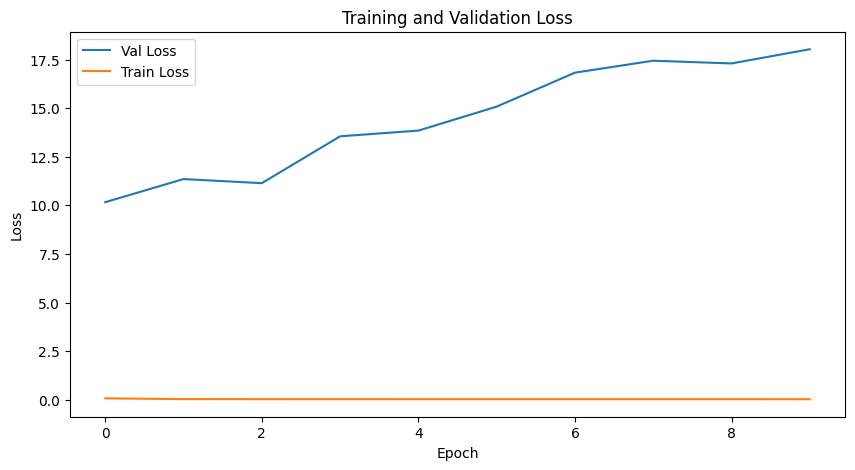

In [57]:
history = train_results.history
plt.figure(figsize=(10, 5))
plt.plot(history.val_loss, label="Val Loss")
plt.plot(history.train_loss, label="Train Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

## 7. 🔗 Pipeline Integration

The ``Pipeline`` class provides a powerful way to chain together all the steps of your machine learning workflow in a single, cohesive structure. This approach ensures reproducibility, reduces boilerplate code, and makes it easier to experiment with different configurations.

The Pipeline in 3WToolkit v2.0.0 follows a sequential execution model where each step processes the data and passes it to the next stage. The pipeline automatically handles data transformations between steps, ensuring compatibility and proper data flow.

________

**Pipeline Execution Flow:**

```markdown
Dataset Loading → Preprocessing → Feature Extraction → Model Training → Model Assessment
```

Each component in the pipeline is configured using its respective configuration class, which encapsulates all the parameters needed for that specific step.

______

### 7.1. Creating a Basic Pipeline

To create a pipeline, you'll need to import the necessary configuration classes and the `Pipeline` class itself:

In [58]:
import matplotlib.pyplot as plt
from ThreeWToolkit.assessment import ModelAssessmentConfig
from ThreeWToolkit.models import MLPConfig
from ThreeWToolkit.trainer import TorchTrainerConfig
from ThreeWToolkit.pipeline import PipelineConfig
from ThreeWToolkit.dataset import ParquetDatasetConfig
from ThreeWToolkit.preprocessing import ImputeMissingConfig, NormalizeConfig
from ThreeWToolkit.feature_extraction import (
    WindowingConfig,
    SequentialFeatureAdapterConfig,
    ConcatFeatureAdapterConfig,
    StatisticalConfig,
    EWStatisticalConfig,
    WaveletConfig,
)
from ThreeWToolkit.dataset import TransformConfig 
from ThreeWToolkit.preprocessing import (
    SequentialPreprocessingAdapterConfig,
    CleanSignalsConfig,
    FillLabelsConfig,
    RemapClassConfig,
)

Now let's create a simple pipeline:

In [59]:
path = "../../dataset"
pipeline = PipelineConfig(
    train_dataset_config=ParquetDatasetConfig(
        path=path,
        version="2.0.0",
        target_column="class",
        target_class=[1, 2],
        force_download=False,
        event_type=["real"],
    ),
    test_dataset_config=ParquetDatasetConfig(
        path=path,
        version="2.0.0",
        target_column="class",
        target_class=[1, 2],
        force_download=False,
        event_type=["drawn"],
    ),
    trainer_config=TorchTrainerConfig(
        config_model=MLPConfig(
            hidden_sizes=(64, 32),
            output_size=5,
        ),
        seed=42,
        epochs=10,
        batch_size=32,
        learning_rate=1e-3,
        device="cpu",
    ),
    pre_transform_config=TransformConfig(
        pre_processing=SequentialPreprocessingAdapterConfig(
            steps=[
                CleanSignalsConfig(missing_column_threshold=0.65),
                FillLabelsConfig(),
                RemapClassConfig(),
            ],
        )
    ),
    transform_config=TransformConfig(
        pre_processing=SequentialPreprocessingAdapterConfig(
            steps=[
                NormalizeConfig(),
                ImputeMissingConfig(),
            ]
        ),
        feature_extraction=SequentialFeatureAdapterConfig(
            steps=[
                WindowingConfig(),
                ConcatFeatureAdapterConfig(
                    steps=[
                        StatisticalConfig(),
                        EWStatisticalConfig(),
                        WaveletConfig(),
                    ]
                ),
            ]
        ),
    ),
).build()

2026-04-15 12:05:16,624 | INFO | ThreeWToolkit.core.base_trainer | Initialized TorchTrainer with seed=42
2026-04-15 12:05:16,624 | INFO | ThreeWToolkit.trainer.torch_trainer | TorchTrainer initialized | device=cpu | epochs=10 | batch_size=32
2026-04-15 12:05:16,628 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-15 12:05:16,629 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-15 12:05:16,629 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!
2026-04-15 12:05:16,650 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset found at ../../dataset
2026-04-15 12:05:16,651 | INFO | ThreeWToolkit.dataset.parquet_dataset | Validating dataset integrity...
2026-04-15 12:05:16,651 | INFO | ThreeWToolkit.dataset.parquet_dataset | Dataset integrity check passed!
2026-04-15 12:05:16,669 | INFO | ThreeWToolkit.pipeline | Pipeline initialized | experiment=experiment


In [60]:
results = pipeline.run()

2026-04-15 12:05:16,679 | INFO | ThreeWToolkit.pipeline | Starting pipeline execution
2026-04-15 12:05:16,680 | INFO | ThreeWToolkit.pipeline | Fitting preprocessing transform on training data...
2026-04-15 12:05:17,247 | INFO | ThreeWToolkit.pipeline | Applying preprocessing transform to training data...
2026-04-15 12:05:17,248 | INFO | ThreeWToolkit.pipeline | Applying preprocessing transform to test data...
2026-04-15 12:05:17,249 | INFO | ThreeWToolkit.pipeline | Fitting transform on training data...
2026-04-15 12:05:17,719 | INFO | ThreeWToolkit.pipeline | Training model...
2026-04-15 12:05:17,720 | INFO | ThreeWToolkit.core.base_trainer | Starting training | train_size=26 | val_size=None
2026-04-15 12:05:17,830 | INFO | ThreeWToolkit.core.base_trainer | Dataset validation passed
2026-04-15 12:05:17,830 | INFO | ThreeWToolkit.core.base_trainer | Preparing training data...
2026-04-15 12:05:17,831 | INFO | ThreeWToolkit.trainer.torch_trainer | Converting dataset to DataLoader (size=

Training:   0%|          | 0/10 [00:00<?, ?epoch/s]

2026-04-15 12:05:19,424 | INFO | ThreeWToolkit.core.base_trainer | Training completed successfully
2026-04-15 12:05:19,425 | INFO | ThreeWToolkit.pipeline | Training complete
2026-04-15 12:05:19,425 | INFO | ThreeWToolkit.pipeline | Training completed
2026-04-15 12:05:19,426 | INFO | ThreeWToolkit.pipeline | Generating predictions...
2026-04-15 12:05:19,426 | INFO | ThreeWToolkit.trainer.torch_trainer | Converting dataset to DataLoader (size=10)
2026-04-15 12:05:20,131 | INFO | ThreeWToolkit.trainer.torch_trainer | Created DataLoader | batches=134
2026-04-15 12:05:20,151 | INFO | ThreeWToolkit.pipeline | Prediction complete


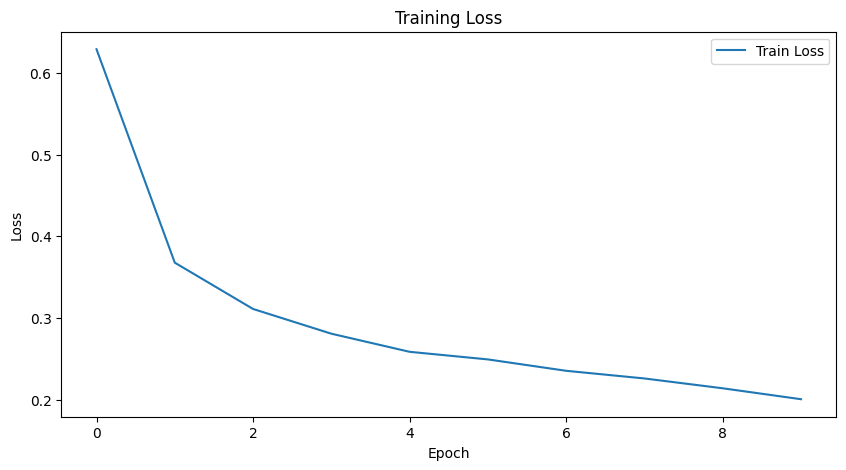

In [62]:
hist = results.training_result.history

plt.figure(figsize=(10, 5))
plt.plot(hist.train_loss, label="Train Loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

### 7.2. Pipeline Components in Detail

**Dataset Configuration**

The `ParquetDatasetConfig` is always the first step in your pipeline. It defines how to load and filter your data:

<div style="font-size:15px">

```python
ParquetDatasetConfig(
    path="./data/raw",                      # Path to your parquet files
    split=None,                             # Train/test split ratio (e.g., 0.8 for 80/20)
    download=False,                         # Whether to download the dataset
    columns=["T-JUS-CKP", "T-MON-CKP"],     # Features to use
    target_column="class",                  # Target variable column name
    target_class=[0, 1],                    # Classes to include (for binary classification)
)

**Preprocessing Steps**

You can chain multiple preprocessing steps. They will be executed in the order they appear:

<div style="font-size:15px">

```python
# Handle missing values
(
    ImputeMissingConfig(
        strategy="median",  # Options: "mean", "median", "forward", "backward"
        columns=["T-JUS-CKP"],  # Specific columns to impute
    ),
)

# Normalize the data
(
    NormalizeConfig(
        norm="l2"  # Options: "l1", "l2", "max", "standard"
    ),
)

**Feature Extraction (Optional)**

**Important:** Only one feature extraction method can be used at a time. Choose the one that best fits your problem:

**Statistical Features**
Extracts basic statistical features like mean, standard deviation, min, max, etc.:

<div style="font-size:15px">

```python
StatisticalConfig(
    features=["mean", "std"],         # Features to extract
)

**Exponentially Weighted Statistical Features**
Extracts statistical features with exponential weighting, giving more importance to recent values:

<div style="font-size:15px">

```python
EWStatisticalConfig(
    selected_features=["ew_mean", "ew_std", "ew_skew"],         # Features to extract
    decay=0.9,                                                  # Exponential decay factor (higher = more weight on recent values)
)


**Wavelet Features** Extracts features using wavelet decomposition:

<div style="font-size:15px">

```python
WaveletConfig(
    level=3,                # Decomposition level
    overlap=0.5,            # Window overlap
    offset=0,               # Starting offset
    wavelet="haar",         # Wavelet type: "haar", "db4", "sym4", etc.
)

**Model Training** 
Configure how your model will be trained, can be either a SklearnTrainerConfig() or a TorchTrainerConfig().

<div style="font-size:15px">

```python
TorchTrainerConfig(
   seed: int = 42,
    use_class_weights: bool = False,
    class_weight_strategy: Literal['balanced', 'manual'] = "balanced",
    manual_class_weights: dict[int, float] | None = None,
    config_model: TorchModelsConfig,
    batch_size: int = 32,
    epochs: int = 50,
    optimizer: type[Optimizer] = optim.Adam,
    learning_rate: float = 0.001,
    optimizer_args: dict[str, Any] = dict,
    criterion: type[Module] = nn.CrossEntropyLoss,
)

<div style="font-size:15px">

```python
SklearnTrainerConfig(
    seed: int = 42,
    use_class_weights: bool = False,
    class_weight_strategy: Literal['balanced', 'manual'] = "balanced",
    manual_class_weights: dict[int, float] | None = None,
    config_model: SklearnModelsConfig,
)

**Model Assessment** Define how to evaluate your model:

<div style="font-size:15px">

```python
ModelAssessmentConfig(
    metrics (list[str]): List of metric names to calculate.
    output_dir (Path): Directory to save assessment results.
    export_results (bool): Whether to export results to CSV files.
    generate_report (bool): Whether to generate LaTeX report using ReportGeneration.
    task_type (TaskTypeEnum): Type of task (TaskTypeEnum.CLASSIFICATION or TaskTypeEnum.REGRESSION).
    report_title (str | None): Title for the report.
    report_author (str): Author name for the report.
)

### 7.3. Complete Pipeline Examples

**Example 1: Pipeline with Statistical Features**

<div style="font-size:15px">

```python
config_model = MLPConfig(
    hidden_sizes=(128, 64, 32),
    output_size=3,
    random_seed=42,
    activation_function="relu",
    regularization=None,
)

pipeline = Pipeline(
    [
        ParquetDatasetConfig(
            path="./data/raw",
            split=0.8,
            download=False,
            columns=["T-JUS-CKP", "T-MON-CKP", "P-PDG"],
            target_column="class",
            target_class=[0, 1, 2],
        ),
        ImputeMissingConfig(strategy="mean", columns=None),  # Impute all columns
        NormalizeConfig(norm="standard"),
        WindowingConfig(window_size=150),
        StatisticalConfig(),  # Extract statistical features
        TrainerConfig(
            optimizer="adam",
            criterion="cross_entropy",
            batch_size=64,
            epochs=50,
            seed=42,
            config_model=config_model,
            learning_rate=0.0005,
            cross_validation=True,
            shuffle_train=True,
        ),
        ModelAssessmentConfig(
            metrics=["balanced_accuracy", "precision", "recall", "f1"],
            task_type=TaskTypeEnum.CLASSIFICATION,
            export_results=True,
            generate_report=True,
        ),
    ]
)

pipeline.run()

**Example 2: Pipeline with Wavelet Features**

<div style="font-size:15px">

```python
config_model = MLPConfig(
    hidden_sizes=(64, 32),
    output_size=2,
    random_seed=11,
    activation_function="tanh",
    regularization="l2",
)

pipeline = Pipeline(
    [
        ParquetDatasetConfig(
            path="../../data/raw",
            split=0.7,
            download=False,
            columns=["T-JUS-CKP", "T-MON-CKP"],
            target_column="class",
            target_class=[0, 1],
        ),
        ImputeMissingConfig(strategy="forward", columns=["T-JUS-CKP", "T-MON-CKP"]),
        NormalizeConfig(norm="l2"),
        WindowingConfig(window_size=200),
        WaveletConfig(
            level=4,
            overlap=0.5,
            offset=0,
            wavelet="db4",  # Daubechies wavelet
        ),
        TrainerConfig(
            optimizer="sgd",
            criterion="cross_entropy",
            batch_size=16,
            epochs=30,
            seed=11,
            config_model=config_model,
            learning_rate=0.01,
            cross_validation=False,
            shuffle_train=True,
        ),
        ModelAssessmentConfig(
            metrics=["balanced_accuracy", "f1"],
            task_type=TaskTypeEnum.CLASSIFICATION,
            export_results=True,
            generate_report=False,
        ),
    ]
)

pipeline.run()

**Example 3: Minimal Pipeline**

<div style="font-size:15px">

```python
config_model = MLPConfig(
    hidden_sizes=(32, 16),
    output_size=3,
    random_seed=42,
    activation_function="relu",
    regularization=None,
)

pipeline = Pipeline(
    [
        ParquetDatasetConfig(
            path="./data/raw",
            split=None,
            download=False,
            columns=["T-JUS-CKP", "T-MON-CKP"],
            target_column="class",
            target_class=[0, 1, 2],
        ),
        TrainerConfig(
            optimizer="adam",
            criterion="cross_entropy",
            batch_size=32,
            epochs=20,
            seed=42,
            config_model=config_model,
            learning_rate=0.001,
            cross_validation=False,
            shuffle_train=True,
        ),
        ModelAssessmentConfig(
            metrics=["balanced_accuracy", "precision", "recall", "f1"],
            task_type=TaskTypeEnum.CLASSIFICATION,
            export_results=True,
            generate_report=False,
        ),
    ]
)

pipeline.run()

### 7.4. Best Practices

**Choosing Feature Extraction Methods**

- **No Feature Extraction:** Use raw windowed data when you have enough data and computational resources. Best for deep learning models.
- **Statistical Features:** Fast and interpretable. Good baseline for most problems.
- **Exponentially Weighted Statistical Features:** When recent observations are more important than older ones (e.g., trending patterns).
- **Wavelet Features:** When you need to capture both time and frequency domain information. Good for signal processing tasks.

**Reproducibility**

Always set random seeds for reproducibility:

<div style="font-size:15px">

```python
config_model = MLPConfig(random_seed=42, ...)
TrainerConfig(seed=42, ...)

**Experiment Tracking**

Enable result export to keep track of your experiments:

<div style="font-size:15px">

```python
ModelAssessmentConfig(
    export_results=True,
    generate_report=True  # For detailed analysis
)

**Pipeline Debugging**

If your pipeline fails, check each component individually. You can comment out steps to isolate issues:

<div style="font-size:15px">

```python
pipeline = Pipeline([
    ParquetDatasetConfig(...),
    ImputeMissingConfig(...),
    # NormalizeConfig(...),  # Temporarily disabled for debugging
    WindowingConfig(...),
    # ... rest of the pipeline
])

After running your pipeline, proceed to analyze the results and iterate on your configuration to improve model performance. Consider experimenting with different feature extraction methods, hyperparameters, and preprocessing strategies.

__________

## 7. Report Generation
The `3WToolkit` provides a `ReportGeneration` module to automatically create comprehensive HTML or LaTeX reports from model evaluation results. This feature simplifies the process of documenting, sharing, and communicating model performance in a standardized format.

The `ReportGeneration` class takes the results from the `ModelAssessment` step and compiles them into a structured report that includes:

- **Model and Dataset Information**: Details about the model, its configuration, and the dataset used.
- **Performance Metrics**: A summary of key metrics like accuracy, precision, recall, and F1-score.
- **Confusion Matrix**: A visualization of the model's performance for each class.
- **Classification Report**: A detailed breakdown of metrics per class.
- **Custom Plots**: The ability to include additional plots, such as feature importance or prediction visualizations.

In this section, we will demonstrate how to generate a report using the evaluation results obtained in the previous step.

In [63]:
from ThreeWToolkit.reports.report_generation import ReportGeneration

model = trainer.model

X_train, y_train = dfs_final.iloc[:, :-1], dfs_final["label"].astype(int)
X_test, y_test = results["X_test"], results["true_values"]
predictions = results["predictions"]

calculated_metrics = results["metrics"]
title = results["config"]["report_title"]
author = results["config"]["report_author"]

plots_config = {
    "PlotSeries": {
        "series": sig["P-TPT"],
        "title": "P-TPT",
        "xlabel": "Timestamp",
        "ylabel": "P-TPT",
        "overlay_events": False,
        "color": "green",
    },  # ['P-TPT', 'T-TPT'],
    "PlotMultipleSeries": {
        "series_list": [sig[["P-MON-CKP"]], sig[["P-TPT"]]],
        "labels": ["P-MON-CKP", "P-TPT"],
        "title": "P-MON-CKP' and 'P-TPT",
        "xlabel": "Timestamp",
        "ylabel": "Value",
    },
    "PlotCorrelationHeatmap": {
        "df_of_series": sig[
            ["P-ANULAR", "P-JUS-CKGL", "P-MON-CKP", "P-TPT", "T-JUS-CKP", "T-TPT"]
        ],
        "title": "Correlation Heatmap of Selected Features",
    },
}

title = "3WToolkit Signal Analysis Report"

report_generation = ReportGeneration(
    model=model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    predictions=predictions,
    calculated_metrics=calculated_metrics,
    plot_config=plots_config,
    title=title,
    author=author,
    export_report_after_generate=False,
)

html_report = report_generation.generate_summary_report(
    template_name="report_template.html", format="html"
)
latex_report = report_generation.generate_summary_report(format="latex")

report_generation.save_report(html_report, "signal_analysis_report", format="html")
report_generation.save_report(latex_report, "signal_analysis_report", format="latex")

NameError: name 'dfs_final' is not defined

### Export to CSV

The 3WToolkit also allows for easy exporting of data, such as model predictions and evaluation results, to CSV format. This is useful for external analysis, sharing, or integration with other data processing pipelines. In this section, we will demonstrate how to save the evaluation results to a CSV file.

In [ ]:
df_results = report_generation.export_results_to_csv(
    results, filename="model_results.csv"
)
df_results.head()

Exporting results to 'model_results.csv'...
Successfully exported results to '/home/thadeu-dias/Documents/3W/toolkit/ThreeWToolkit/reports/report-3WToolkit Signal Analysis Report/model_results.csv'.


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_98,feature_99,feature_100,true_values,predictions,model_name,balanced_accuracy,precision,recall,f1
0,0.0,0.000717,0.002863,0.006432,0.011408,0.017773,0.025500,0.034560,0.044916,0.056528,...,0.006432,0.002863,0.000717,0,0,MLP,0.924828,0.937183,0.937006,0.937057
1,0.0,0.000717,0.002863,0.006432,0.011408,0.017773,0.025500,0.034560,0.044916,0.056529,...,0.006432,0.002863,0.000717,0,0,MLP,0.924828,0.937183,0.937006,0.937057
2,0.0,0.000717,0.002863,0.006432,0.011408,0.017773,0.025500,0.034560,0.044917,0.056529,...,0.006432,0.002863,0.000717,0,0,MLP,0.924828,0.937183,0.937006,0.937057
3,0.0,0.000717,0.002863,0.006432,0.011409,0.017773,0.025501,0.034561,0.044917,0.056530,...,0.006432,0.002863,0.000717,0,0,MLP,0.924828,0.937183,0.937006,0.937057
4,0.0,0.000717,0.002863,0.006432,0.011409,0.017773,0.025501,0.034561,0.044918,0.056530,...,0.006432,0.002864,0.000717,0,0,MLP,0.924828,0.937183,0.937006,0.937057
